In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ranamuhammmadusman/oil-seeds-dataset-production-and-yield-analysis/oil_seeds_punjab_agricultural_data.csv


# Problem Statement

Agricultural production is influenced by multiple factors such as climate, soil conditions, and resource management. Understanding these relationships can help improve crop productivity and decision-making. In this notebook, we analyze oilseed crop data from Punjab and apply machine learning models to predict crop production.

**Why AI Adoption Matters**

* Better Decision Making: AI helps farmers and policymakers analyze large agricultural datasets.

* Improved Productivity: Identifying patterns can help optimize crop yield and resource usage.

* Sustainable Farming: Data-driven insights support efficient water, soil, and climate management.

**Objectives of this Notebook**

* Explore the Dataset: Understand the structure and key variables of the oilseed production data.

* Perform EDA: Identify trends and relationships between environmental and production factors.

* Build ML Models: Train and compare multiple machine learning models for production prediction.

* Find Key Drivers: Discover the most important factors influencing crop yield and production.

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR


# Load Dataset

In [3]:

path = "/kaggle/input/datasets/ranamuhammmadusman/oil-seeds-dataset-production-and-yield-analysis/oil_seeds_punjab_agricultural_data.csv"
df = pd.read_csv(path)

print("Dataset Shape:", df.shape)
print(df.head())


Dataset Shape: (78, 16)
   Year  Crop_Name Crop_Type District_Name  Area_Hectares  Production_Tonnes  \
0  2020  Sunflower   Oilseed         Okara          12500              18750   
1  2020  Sunflower   Oilseed         Jhang          11200              16240   
2  2020  Sunflower   Oilseed    Faisalabad          15000              22500   
3  2020  Sunflower   Oilseed       Sahiwal           8900              11680   
4  2020  Sunflower   Oilseed    Gujranwala           7500               9750   

   Yield_Kg_Per_Hectare  Season  Temperature_Celsius_Avg  Rainfall_MM  \
0                  1500  Spring                     32.5          425   
1                  1450  Spring                     31.8          390   
2                  1500  Spring                     33.2          410   
3                  1312  Spring                     32.1          380   
4                  1300  Spring                     31.5          415   

   Irrigation_Requirement_MM   Soil_Type  Market_Price_P

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78 entries, 0 to 77
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Year                       78 non-null     int64  
 1   Crop_Name                  78 non-null     object 
 2   Crop_Type                  78 non-null     object 
 3   District_Name              78 non-null     object 
 4   Area_Hectares              78 non-null     int64  
 5   Production_Tonnes          78 non-null     int64  
 6   Yield_Kg_Per_Hectare       78 non-null     int64  
 7   Season                     78 non-null     object 
 8   Temperature_Celsius_Avg    78 non-null     float64
 9   Rainfall_MM                78 non-null     int64  
 10  Irrigation_Requirement_MM  78 non-null     int64  
 11  Soil_Type                  78 non-null     object 
 12  Market_Price_PKR_Per_Kg    78 non-null     int64  
 13  Export_Status              78 non-null     object 
 

In [5]:
df.describe()

,Year,Area_Hectares,Production_Tonnes,Yield_Kg_Per_Hectare,Temperature_Celsius_Avg,Rainfall_MM,Irrigation_Requirement_MM,Market_Price_PKR_Per_Kg,Purity_Percent
count,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000
mean,2022.500000,12116.666667,18833.205128,1338.615385,28.273077,510.320513,219.615385,90.679487,97.011538
std,1.718879,6750.688597,15350.553334,441.423825,7.283047,135.743120,77.420966,27.957061,1.335332
min,2020.000000,2100.000000,1680.000000,800.000000,17.200000,280.000000,100.000000,44.000000,93.800000
25%,2021.000000,7575.000000,7505.000000,950.000000,19.800000,402.500000,150.000000,68.500000,96.200000
50%,2022.500000,10900.000000,13650.000000,1300.000000,32.450000,470.000000,250.000000,86.000000,97.100000
75%,2024.000000,15575.000000,26625.000000,1500.000000,34.100000,650.000000,270.000000,114.250000,98.000000
max,2025.000000,29500.000000,59000.000000,2000.000000,36.700000,750.000000,320.000000,152.000000,99.700000


In [6]:

print("\nMissing Values\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nSummary\n", df.describe())


Missing Values
 Year                         0
Crop_Name                    0
Crop_Type                    0
District_Name                0
Area_Hectares                0
Production_Tonnes            0
Yield_Kg_Per_Hectare         0
Season                       0
Temperature_Celsius_Avg      0
Rainfall_MM                  0
Irrigation_Requirement_MM    0
Soil_Type                    0
Market_Price_PKR_Per_Kg      0
Export_Status                0
Quality_Grade                0
Purity_Percent               0
dtype: int64

Duplicates: 0

Summary
               Year  Area_Hectares  Production_Tonnes  Yield_Kg_Per_Hectare  \
count    78.000000      78.000000          78.000000             78.000000   
mean   2022.500000   12116.666667       18833.205128           1338.615385   
std       1.718879    6750.688597       15350.553334            441.423825   
min    2020.000000    2100.000000        1680.000000            800.000000   
25%    2021.000000    7575.000000        7505.000000       

# Feature Engineering

In [7]:

df["Production_per_Hectare"] = df["Production_Tonnes"] / df["Area_Hectares"]

df["Water_Efficiency"] = df["Yield_Kg_Per_Hectare"] / df["Irrigation_Requirement_MM"]

df["Climate_Index"] = (
    df["Temperature_Celsius_Avg"] * 0.5 +
    df["Rainfall_MM"] * 0.5
)


# EDA Visualizations

## Crop Distribution

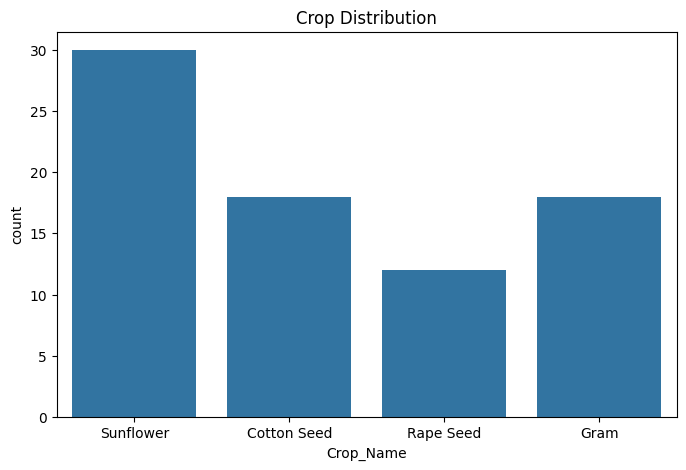

In [8]:

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Crop_Name")
plt.title("Crop Distribution")
plt.show()

## Crop Type Distribution"

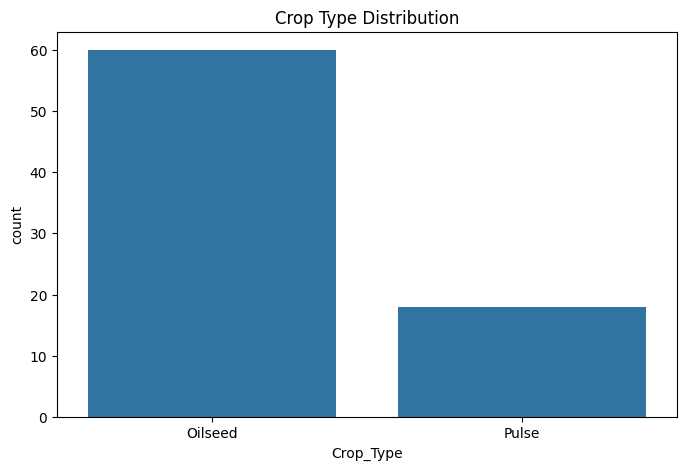

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Crop_Type")
plt.title("Crop Type Distribution")
plt.show()

## Production Trend by Crop

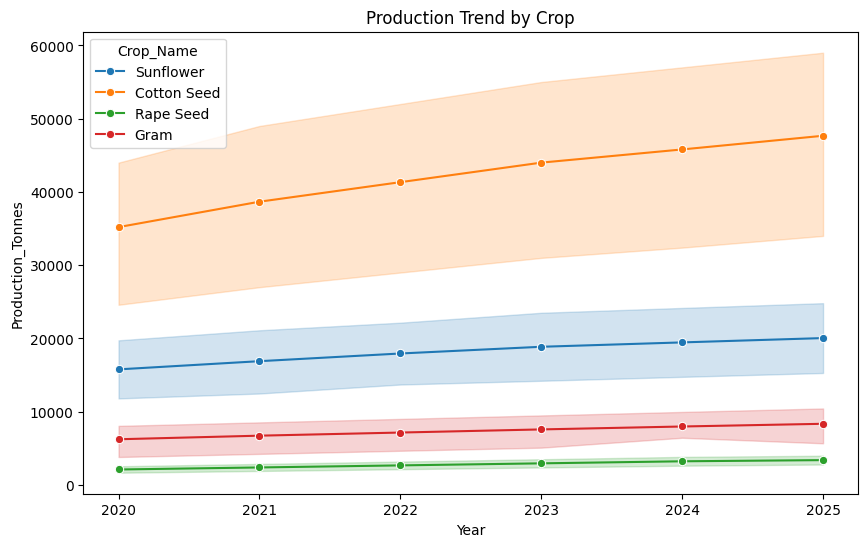

In [10]:
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x="Year", y="Production_Tonnes", hue="Crop_Name", marker="o")
plt.title("Production Trend by Crop")
plt.show()

## Price Trend by Crop

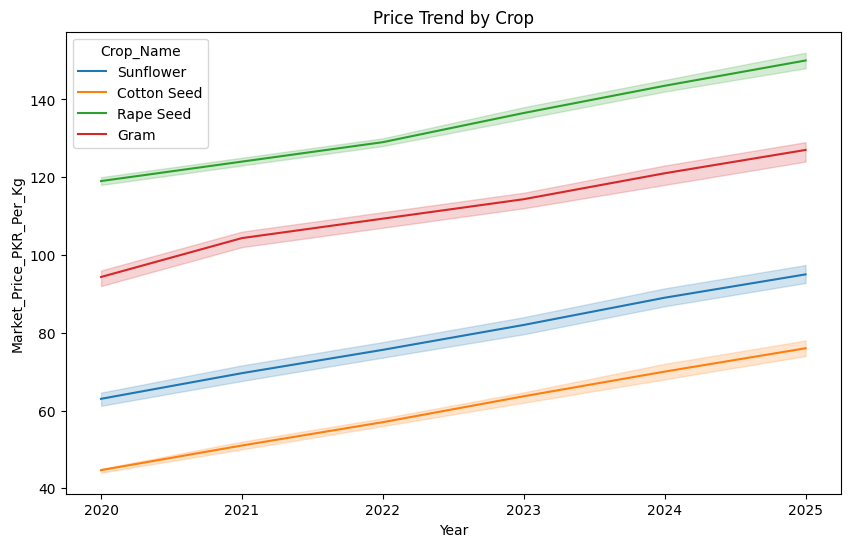

In [11]:
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x="Year", y="Market_Price_PKR_Per_Kg", hue="Crop_Name")
plt.title("Price Trend by Crop")
plt.show()

## Area vs Production

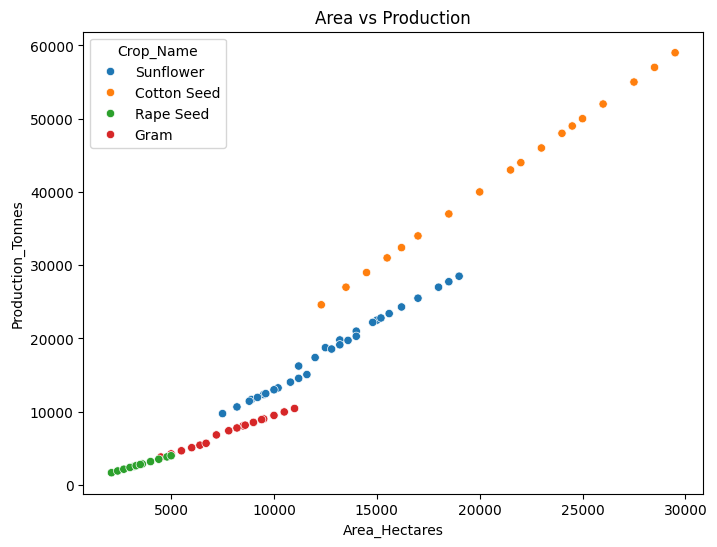

In [12]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="Area_Hectares", y="Production_Tonnes", hue="Crop_Name")
plt.title("Area vs Production")
plt.show()

## Rainfall vs Yield

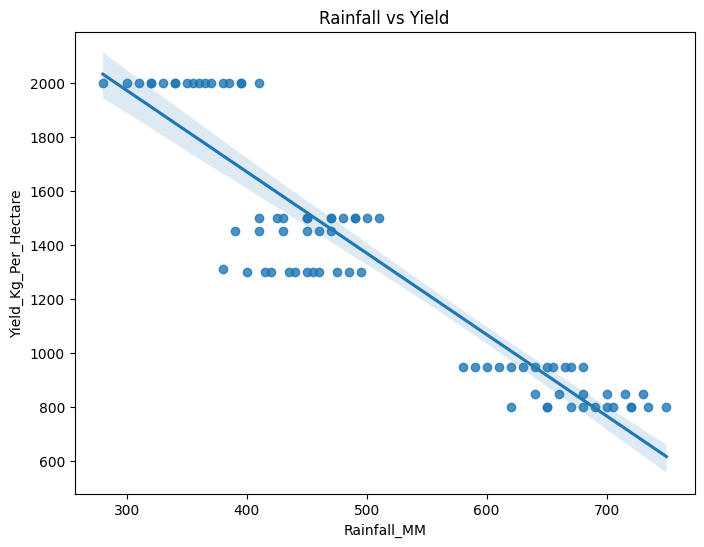

In [13]:
plt.figure(figsize=(8,6))
sns.regplot(data=df, x="Rainfall_MM", y="Yield_Kg_Per_Hectare")
plt.title("Rainfall vs Yield")
plt.show()


## Temperature Impact on Yield

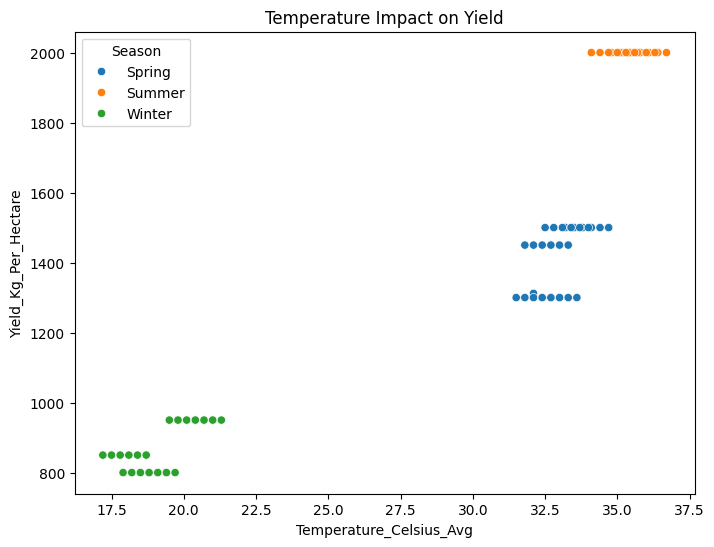

In [14]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="Temperature_Celsius_Avg", y="Yield_Kg_Per_Hectare", hue="Season")
plt.title("Temperature Impact on Yield")
plt.show()

## Production by District

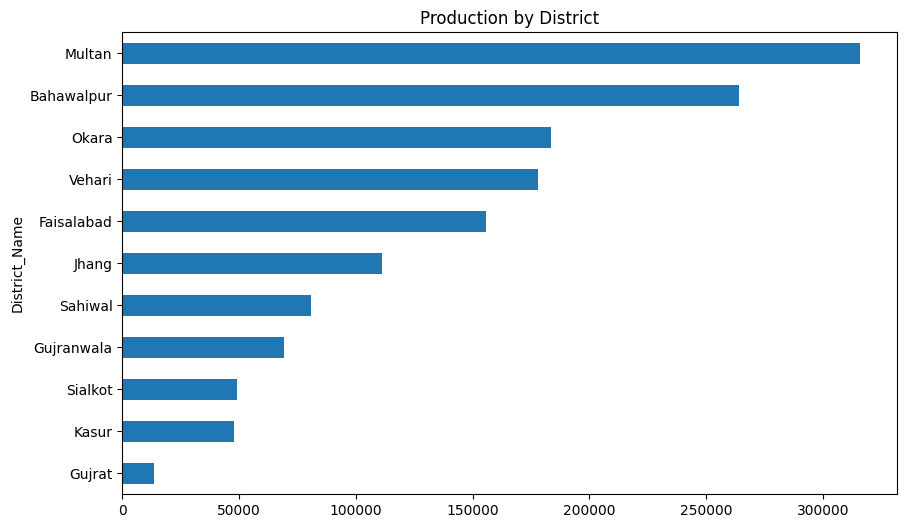

In [15]:
plt.figure(figsize=(10,6))
district = df.groupby("District_Name")["Production_Tonnes"].sum().sort_values()
district.plot(kind="barh")
plt.title("Production by District")
plt.show()

## Season vs Yield

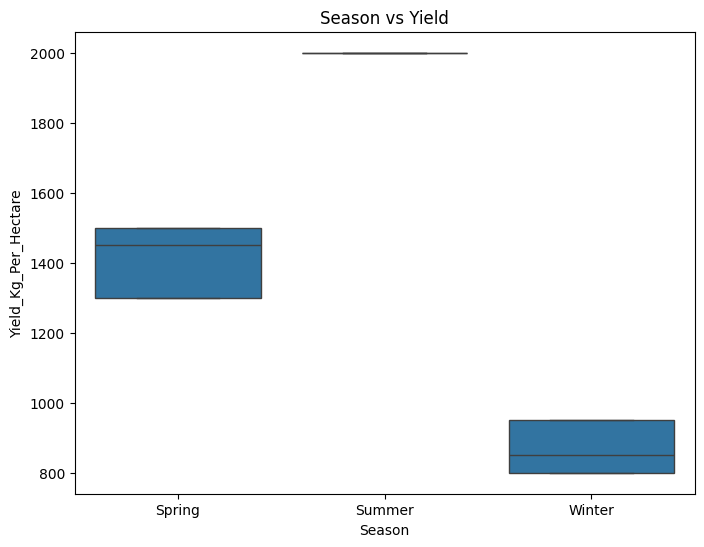

In [16]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x="Season", y="Yield_Kg_Per_Hectare")
plt.title("Season vs Yield")
plt.show()

## Soil Type vs Yield

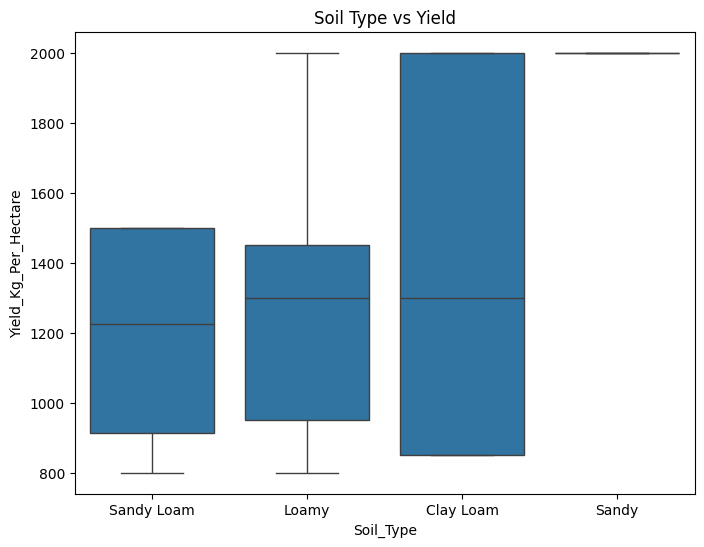

In [17]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x="Soil_Type", y="Yield_Kg_Per_Hectare")
plt.title("Soil Type vs Yield")
plt.show()


## Purity vs Price

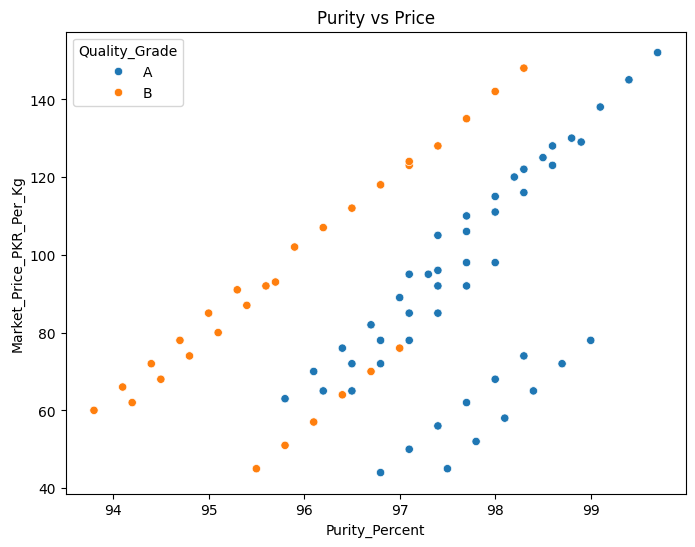

In [18]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="Purity_Percent", y="Market_Price_PKR_Per_Kg", hue="Quality_Grade")
plt.title("Purity vs Price")
plt.show()

## Export Status vs Price

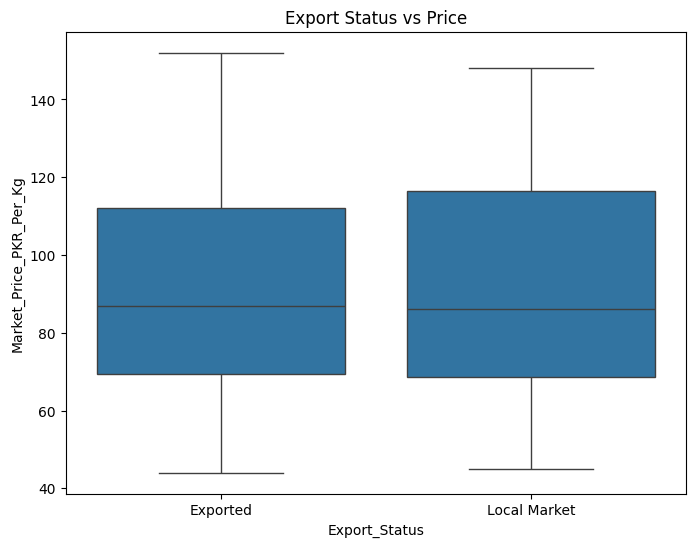

In [19]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x="Export_Status", y="Market_Price_PKR_Per_Kg")
plt.title("Export Status vs Price")
plt.show()

## Price vs Purity Regression

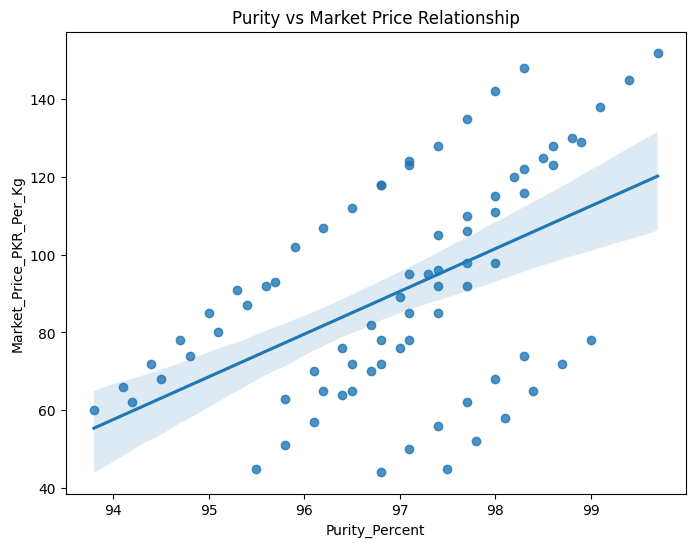

In [20]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="Purity_Percent",
    y="Market_Price_PKR_Per_Kg"
)

plt.title("Purity vs Market Price Relationship")
plt.show()

## Purity Distribution

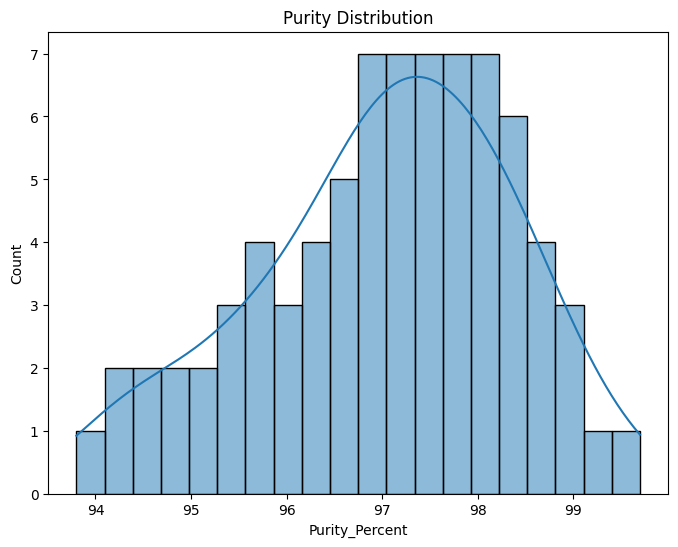

In [21]:
plt.figure(figsize=(8,6))
sns.histplot(df["Purity_Percent"], bins=20, kde=True)
plt.title("Purity Distribution")
plt.show()

## Production Distribution

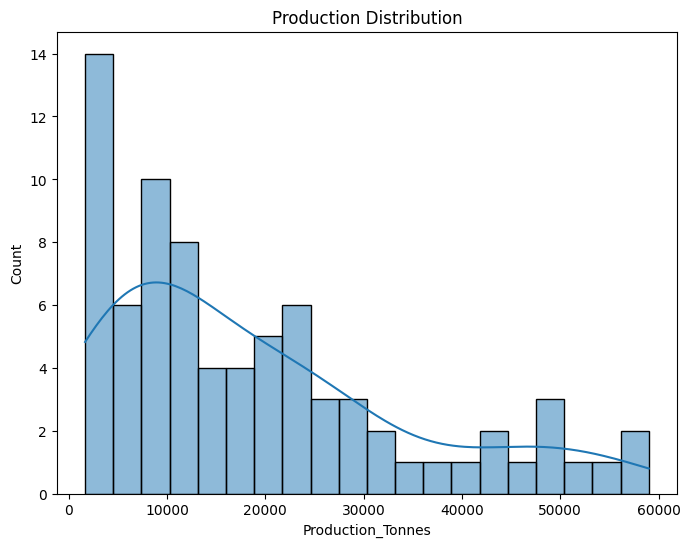

In [22]:
plt.figure(figsize=(8,6))
sns.histplot(df["Production_Tonnes"], bins=20, kde=True)
plt.title("Production Distribution")
plt.show()

## Correlation Heatmap

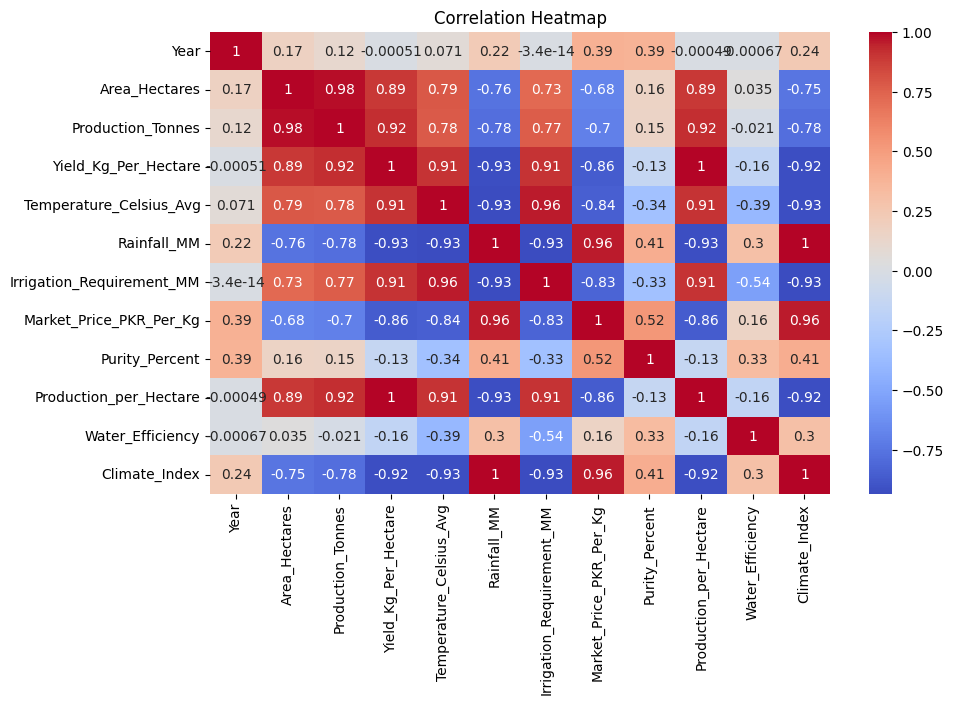

In [23]:

plt.figure(figsize=(10,6))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## District vs Crop Production Heatmap

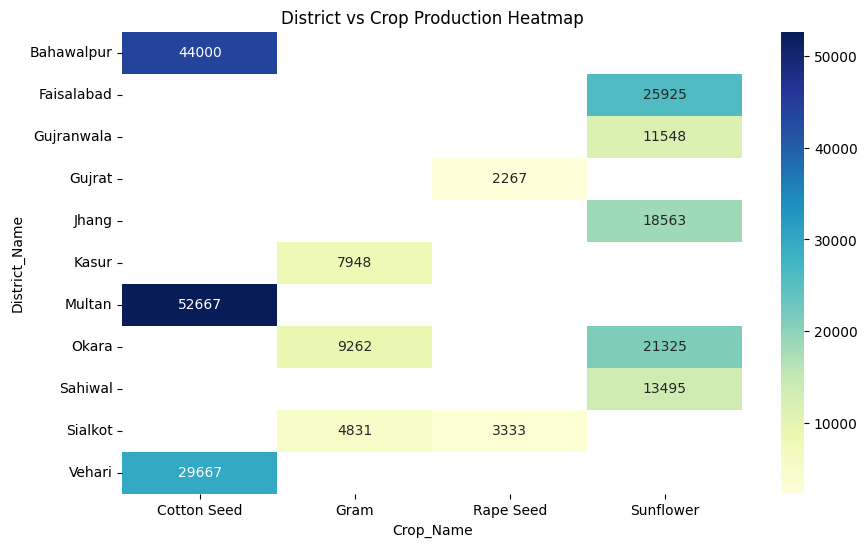

In [24]:
pivot = df.pivot_table(
    values="Production_Tonnes",
    index="District_Name",
    columns="Crop_Name",
    aggfunc="mean"
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, cmap="YlGnBu", fmt=".0f")
plt.title("District vs Crop Production Heatmap")
plt.show()

## Crop Yield Radar Chart

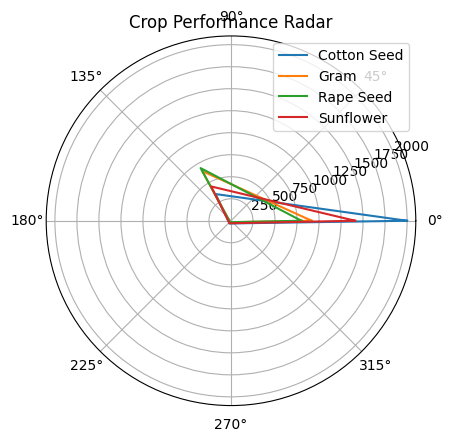

In [25]:
from math import pi

crop_stats = df.groupby("Crop_Name")[["Yield_Kg_Per_Hectare","Rainfall_MM","Temperature_Celsius_Avg"]].mean()

labels = crop_stats.columns
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)

for crop in crop_stats.index:
    
    values = crop_stats.loc[crop].values
    values = np.concatenate((values,[values[0]]))
    ang = np.concatenate((angles,[angles[0]]))
    
    plt.polar(ang, values, label=crop)

plt.title("Crop Performance Radar")
plt.legend()
plt.show()

## Pairplot

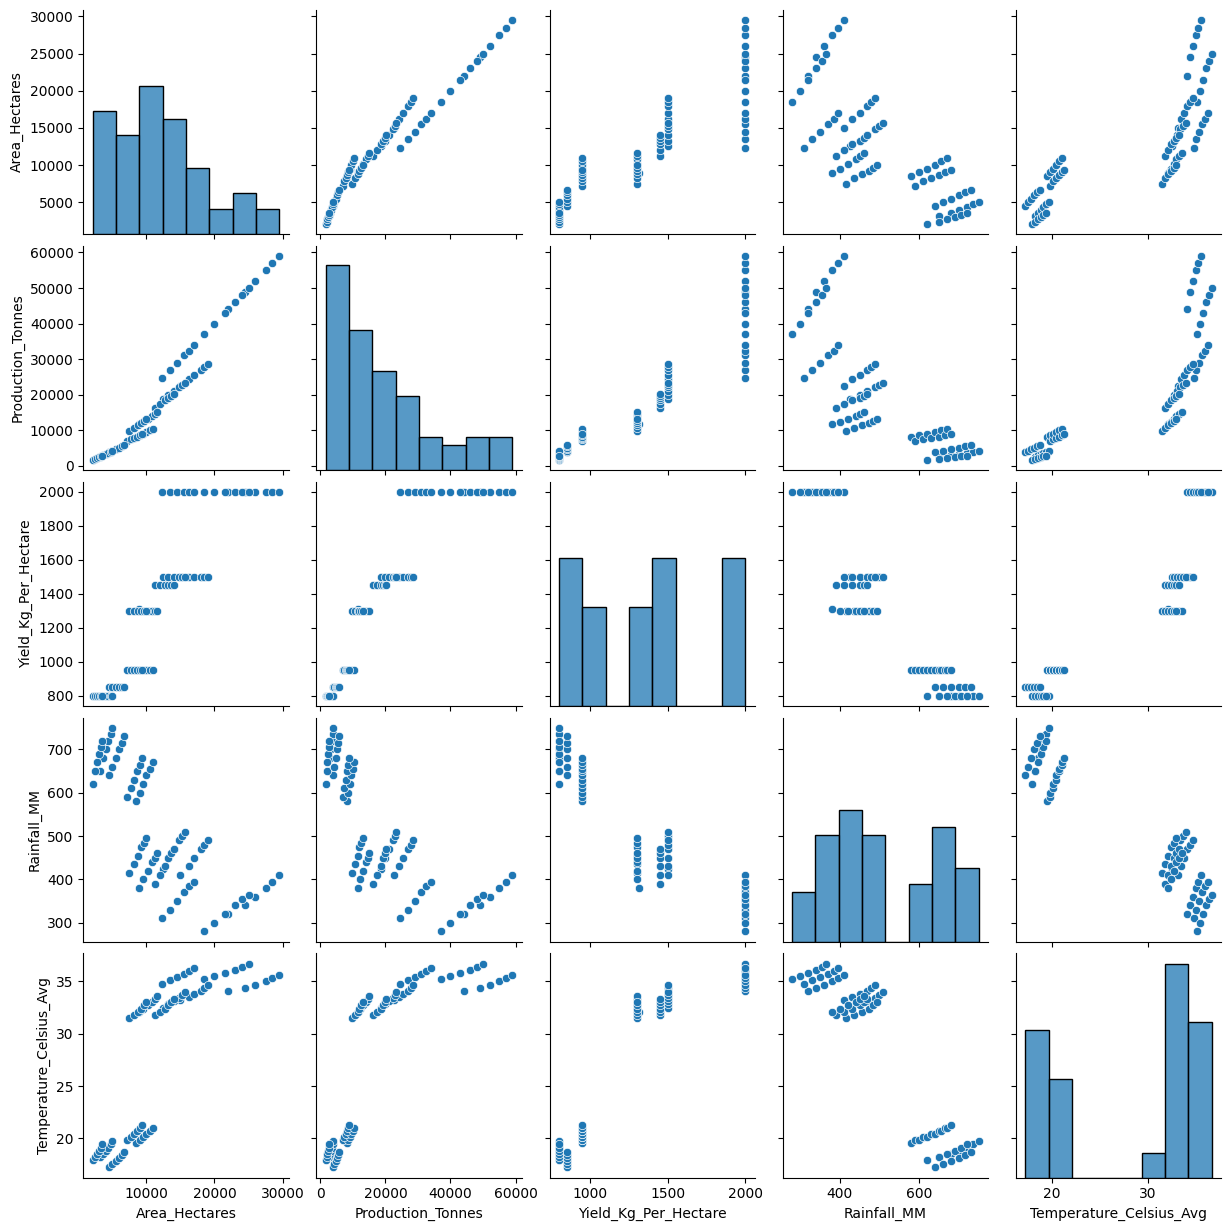

In [26]:
sns.pairplot(
    df[[
        "Area_Hectares",
        "Production_Tonnes",
        "Yield_Kg_Per_Hectare",
        "Rainfall_MM",
        "Temperature_Celsius_Avg"
    ]]
)

plt.show()

## Violin Plot

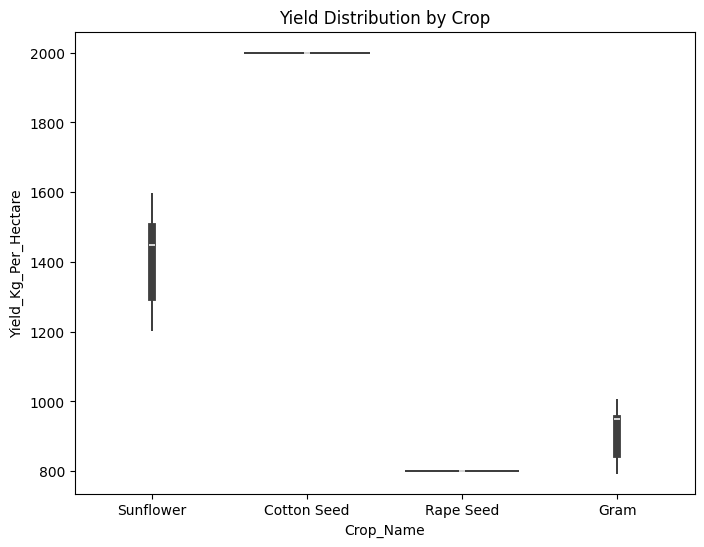

In [27]:
plt.figure(figsize=(8,6))

sns.violinplot(
    data=df,
    x="Crop_Name",
    y="Yield_Kg_Per_Hectare"
)

plt.title("Yield Distribution by Crop")
plt.show()

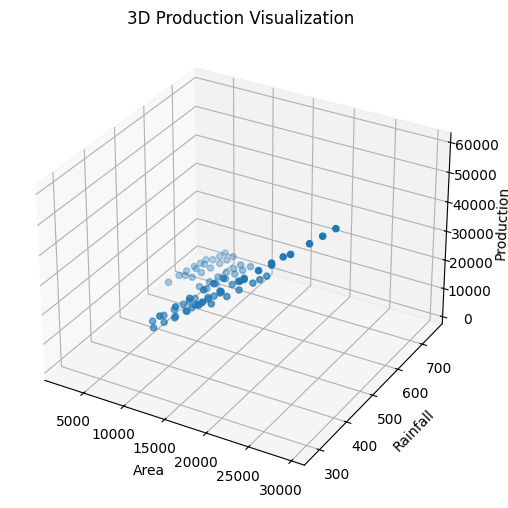

In [28]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df["Area_Hectares"],
    df["Rainfall_MM"],
    df["Production_Tonnes"]
)

ax.set_xlabel("Area")
ax.set_ylabel("Rainfall")
ax.set_zlabel("Production")

plt.title("3D Production Visualization")
plt.show()

## Clustering Analysis


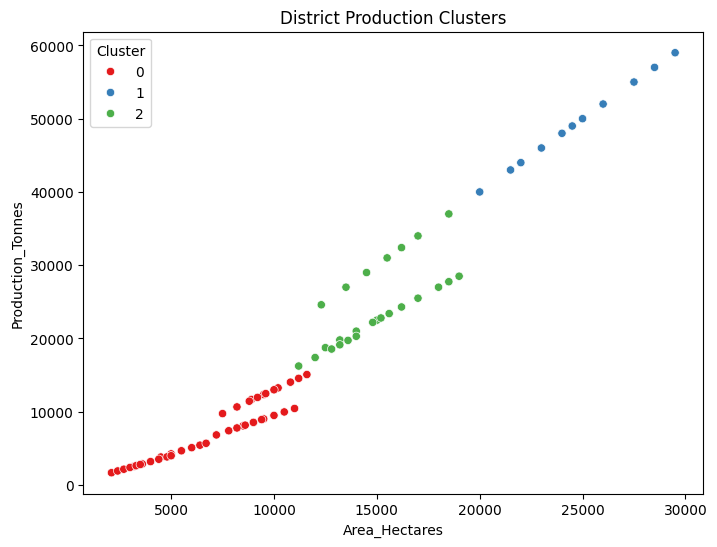

In [29]:
from sklearn.cluster import KMeans

cluster_data = df[[
    "Area_Hectares",
    "Production_Tonnes",
    "Yield_Kg_Per_Hectare"
]]

kmeans = KMeans(n_clusters=3, random_state=42)

df["Cluster"] = kmeans.fit_predict(cluster_data)

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Area_Hectares",
    y="Production_Tonnes",
    hue="Cluster",
    palette="Set1"
)

plt.title("District Production Clusters")
plt.show()

## Cluster Heatmap

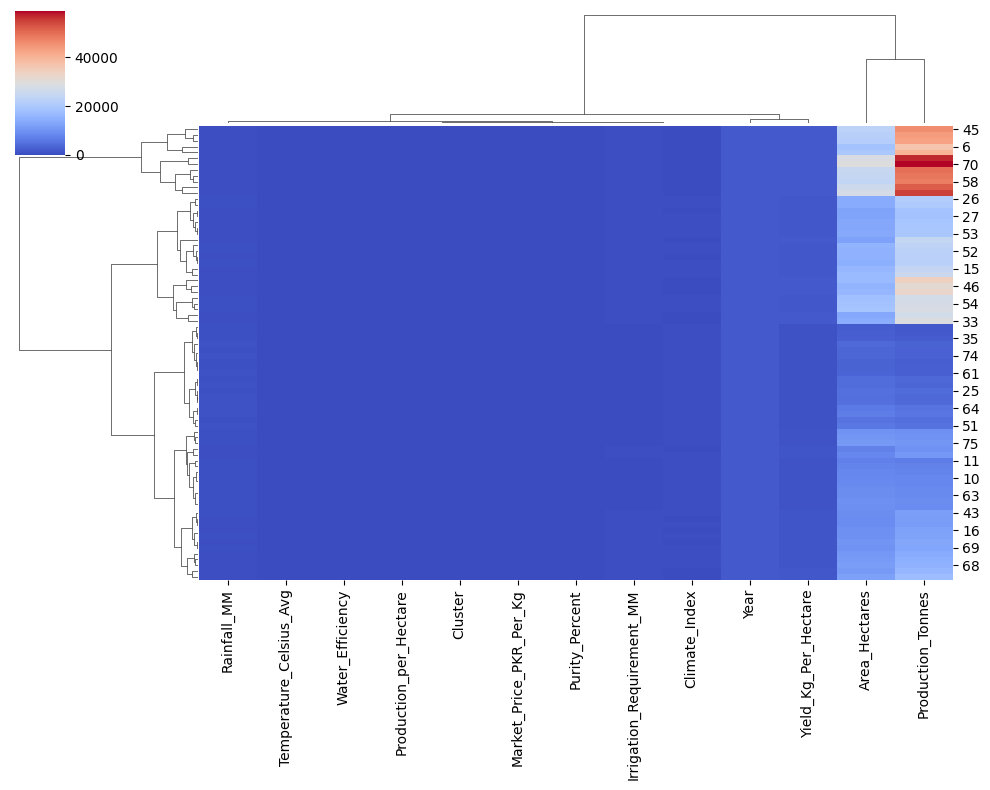

In [30]:
sns.clustermap(
    df.select_dtypes(include=np.number),
    cmap="coolwarm",
    figsize=(10,8)
)

## Production Growth Rate

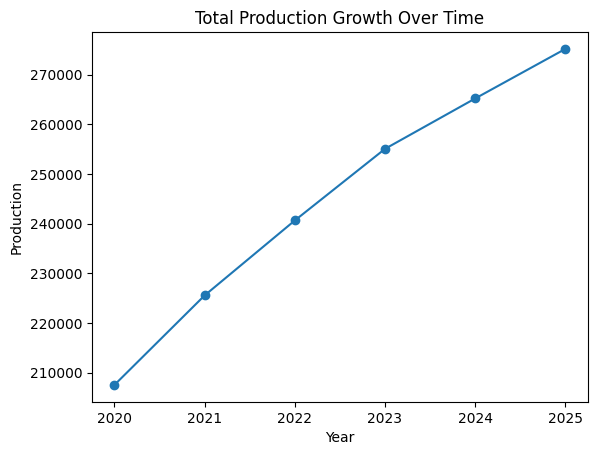

In [31]:
growth = df.groupby("Year")["Production_Tonnes"].sum()

growth.plot(marker="o")

plt.title("Total Production Growth Over Time")
plt.ylabel("Production")
plt.show()

# Prepare Data

In [32]:

df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop("Production_Tonnes", axis=1)
y = df_encoded["Production_Tonnes"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Machine Learning Models

In [33]:

models = {

"Linear Regression": LinearRegression(),
"Ridge": Ridge(),
"Lasso": Lasso(),
"ElasticNet": ElasticNet(),
"Decision Tree": DecisionTreeRegressor(),
"Random Forest": RandomForestRegressor(),
"Extra Trees": ExtraTreesRegressor(),
"Gradient Boosting": GradientBoostingRegressor(),
"AdaBoost": AdaBoostRegressor(),
"KNN": KNeighborsRegressor(),
"SVR": SVR()

}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    r2 = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))

    cv = cross_val_score(model, X_train, y_train, cv=5, scoring="r2").mean()

    results.append([name, r2, mae, rmse, cv])

results_df = pd.DataFrame(
    results,
    columns=["Model","R2","MAE","RMSE","CV Score"]
)

print("\nModel Performance")
display(results_df.sort_values("R2", ascending=False))


Model Performance


,Model,R2,MAE,RMSE,CV Score
0,Linear Regression,0.999766,191.178138,246.468173,0.998446
2,Lasso,0.999703,209.916009,277.734211,0.999502
7,Gradient Boosting,0.998571,412.649021,609.276059,0.970848
6,Extra Trees,0.998354,351.656250,653.922529,0.987352
1,Ridge,0.997652,645.054098,780.836033,0.989204
4,Decision Tree,0.990967,1203.750000,1531.657599,0.916628
5,Random Forest,0.989577,984.853125,1645.292547,0.964655
9,KNN,0.989066,1376.250000,1685.130522,0.944514
3,ElasticNet,0.988769,1220.955489,1707.880752,0.970786
8,AdaBoost,0.986443,1463.841384,1876.406131,0.959490


# Model Comparison Visualization

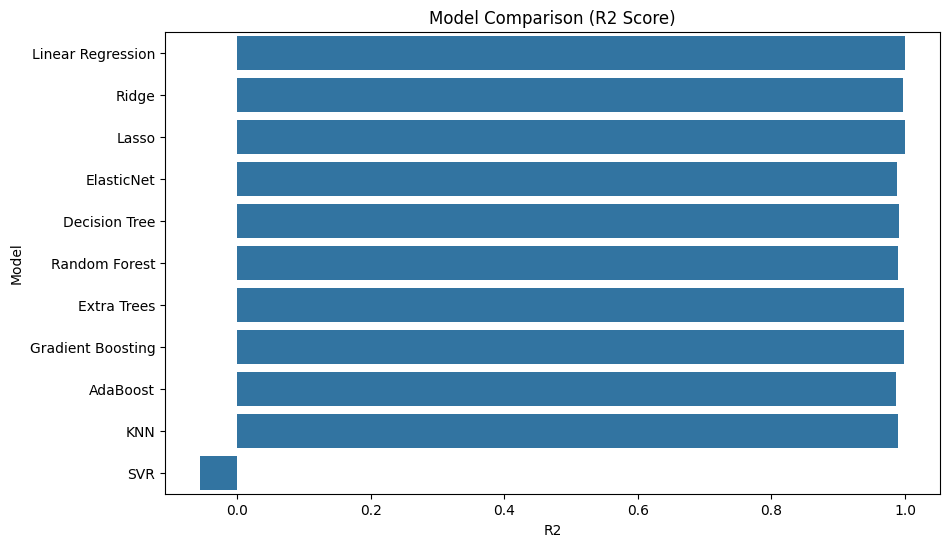

In [34]:
plt.figure(figsize=(10,6))
sns.barplot(data=results_df, x="R2", y="Model")
plt.title("Model Comparison (R2 Score)")
plt.show()

# Feature Importance

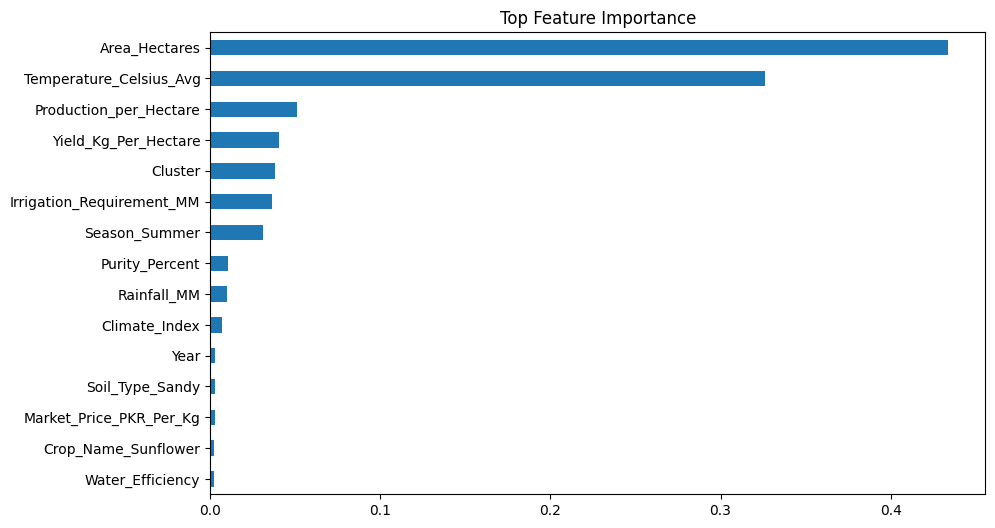

In [35]:

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
importance.sort_values().plot(kind="barh")
plt.title("Top Feature Importance")
plt.show()


# Prediction Visualization

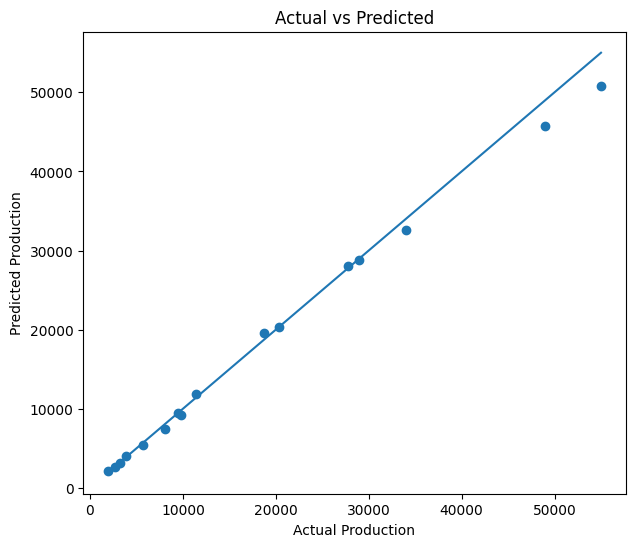

In [36]:


pred = rf.predict(X_test)

plt.figure(figsize=(7,6))
plt.scatter(y_test, pred)
plt.xlabel("Actual Production")
plt.ylabel("Predicted Production")
plt.title("Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.show()

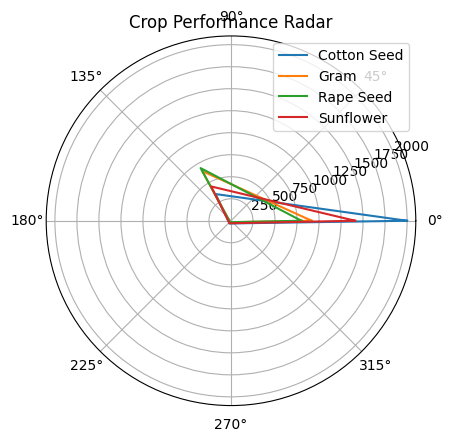

In [37]:
from math import pi

crop_stats = df.groupby("Crop_Name")[["Yield_Kg_Per_Hectare","Rainfall_MM","Temperature_Celsius_Avg"]].mean()

labels = crop_stats.columns
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)

for crop in crop_stats.index:
    
    values = crop_stats.loc[crop].values
    values = np.concatenate((values,[values[0]]))
    ang = np.concatenate((angles,[angles[0]]))
    
    plt.polar(ang, values, label=crop)

plt.title("Crop Performance Radar")
plt.legend()
plt.show()

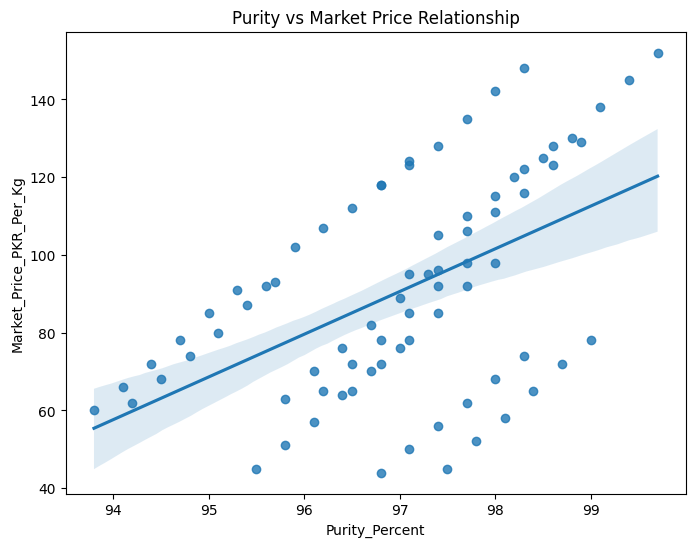

In [38]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="Purity_Percent",
    y="Market_Price_PKR_Per_Kg"
)

plt.title("Purity vs Market Price Relationship")
plt.show()

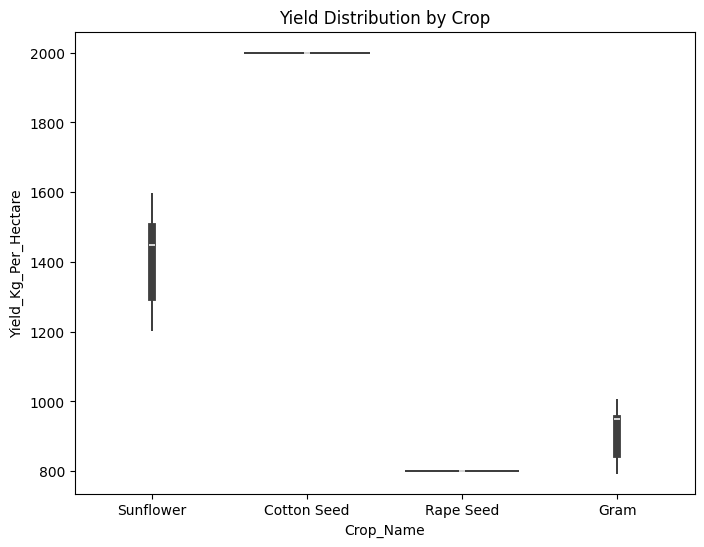

In [39]:
plt.figure(figsize=(8,6))

sns.violinplot(
    data=df,
    x="Crop_Name",
    y="Yield_Kg_Per_Hectare"
)

plt.title("Yield Distribution by Crop")
plt.show()

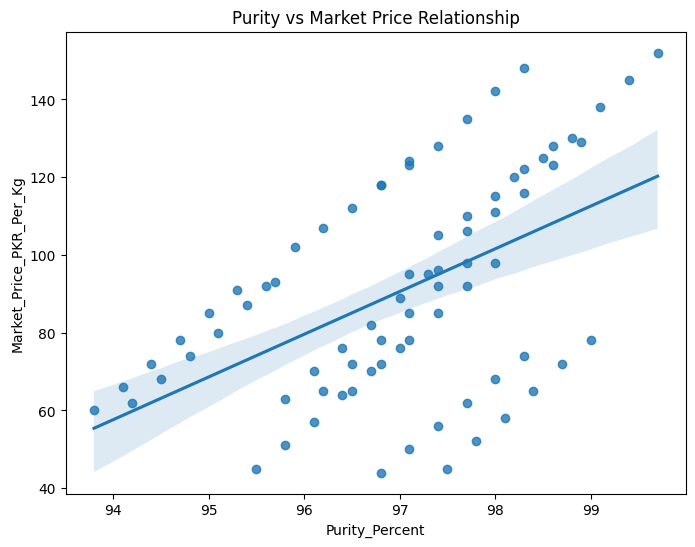

In [40]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x="Purity_Percent",
    y="Market_Price_PKR_Per_Kg"
)

plt.title("Purity vs Market Price Relationship")
plt.show()

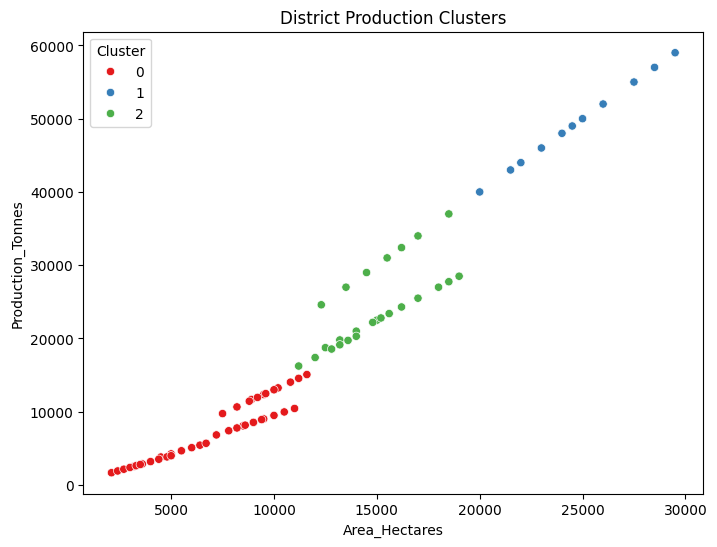

In [41]:
from sklearn.cluster import KMeans

cluster_data = df[[
    "Area_Hectares",
    "Production_Tonnes",
    "Yield_Kg_Per_Hectare"
]]

kmeans = KMeans(n_clusters=3, random_state=42)

df["Cluster"] = kmeans.fit_predict(cluster_data)

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Area_Hectares",
    y="Production_Tonnes",
    hue="Cluster",
    palette="Set1"
)

plt.title("District Production Clusters")
plt.show()

# Overall Summary

In this notebook, we performed a complete data science workflow on agricultural data.

**The process included:**

• Data exploration and cleaning

• Advanced exploratory data analysis

• Feature engineering

• Machine learning modeling

• Model comparison and evaluation

The results demonstrate that data-driven approaches can provide valuable insights into agricultural productivity and crop management.

By applying machine learning to farming data, stakeholders can better understand the impact of environmental factors, optimize crop production, and support smarter agricultural decisions.